# Fusion tutorial #2 - Energy Physics II with Nuclear Energy

In this tutorial we will solve the equations of motion for a charged particle in a magnetic field numerically and compare with the expected behavior derived analytically during the lectures. The equations of motions (in the absence of any electric field) are given by

$$
\begin{aligned}
\frac{d\mathbf{v}}{dt} &= \frac{q}{m} \mathbf{v} \times \mathbf{B} \\
\frac{d\mathbf{r}}{dt} &= \mathbf{v}
\end{aligned}
$$

In component form this becomes (Cartesian coordinates are used throughout this tutorial):

$$
\begin{aligned}
\frac{dv_x}{dt} &= \frac{q}{m} (v_y B_z - v_z B_y) \\
\frac{dv_y}{dt} &= -\frac{q}{m} (v_x B_z - v_z B_x) \\
\frac{dv_z}{dt} &= \frac{q}{m} (v_x B_y - v_y B_x) \\
\frac{dx}{dt} &= v_x \\
\frac{dy}{dt} &= v_y \\
\frac{dz}{dt} &= v_z \\
\end{aligned}
$$

We start by setting up a basic framework for integrating the above system of ordinary differential equations, using the `solve_ivp` function from `scipy`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.constants as const

# Mass and charge of the particle
q = const.e             # Coulomb
m = const.proton_mass   # kg

We start by considering the case without any B-field:

In [2]:
def zero_B_field(x, y, z):
    """A B-field that is zero everywhere."""
    Bx = 0.0
    By = 0.0
    Bz = 0.0
    return Bx, By, Bz

Define the functions necessary to solve the ODE's:

In [3]:
def eval_B_field(x, y, z):
    """Evaluate the B-field (in Tesla) specified by the function `Bfun` at given (x,y,z) coordinates."""
    
    Bx, By, Bz = Bfun(x, y, z)
    
    return np.array([Bx, By, Bz])

def eval_ode_rhs(t, Y):
    """Evaluate the right hand side of the equations of motion."""
    
    v = Y[:3]
    x = Y[3]
    y = Y[4]
    z = Y[5]

    # Evaluate the cross product in the Lorenz force
    B = eval_B_field(x, y, z)  # Tesla
    vxB = np.cross(v, B)

    # Specify all terms on the RHS of the equations of motion
    rhs = np.zeros_like(Y)
    rhs[:3] = q * vxB / m
    rhs[3:] = Y[:3]
    
    return rhs

It will also be useful to have a function for converting between the energy (keV) and the speed (m/s) of the particle, and for plotting the solution:

In [4]:
def E2v(E_keV, m_kg):
    """Convert the energy of a particle to speed (m/s)."""
    E_Joule = E_keV * const.e * 1000
    v = np.sqrt(2*E_Joule/m_kg)
    return v

def get_sol_data(sol):
    """Helper function for extracting the relevant part of the ODE solution."""
    t = sol['t']
    vx = sol['y'][0]
    vy = sol['y'][1]
    vz = sol['y'][2]
    x =  sol['y'][3]
    y =  sol['y'][4]
    z =  sol['y'][5]

    return t, vx, vy, vz, x, y, z

def plot_orbit_3d(sol):
    # Plot the results
    fig = plt.figure('Orbit 3D')
    ax = fig.add_subplot(projection='3d')
    ax.view_init(elev=55, azim=55, roll=135)

    # Plot (x,y,z) coordinates of the solution
    t, vx, vy, vz, x, y, z = get_sol_data(sol)
    ax.plot(x, y, z)

    # Mark initial position with a red star
    ax.plot(x[0], y[0], z[0], 'r*')
    
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_zlabel('z (m)')
    plt.axis('equal')
    plt.tight_layout()

Now we can solve the equations of motion for the simple case of a particle moving along the x-axis without the influence af any B-field:

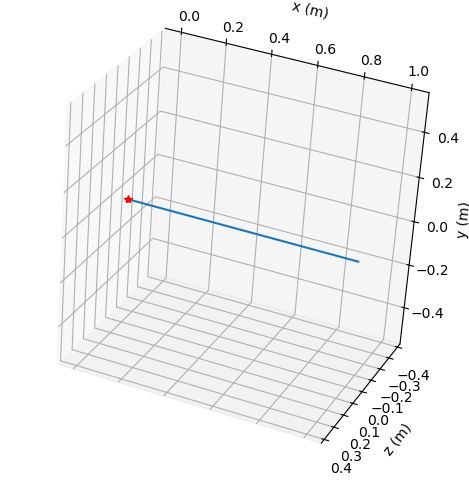

In [5]:
E0 = 20         # keV
v0 = E2v(E0, m) # m/s
vx0 = v0        # m/s
vy0 = 0.0       # m/s
vz0 = 0.0       # m/s
x0 = 0.0        # m
y0 = 0.0        # m
z0 = 0.0        # m

# Initial value vector
Y0 = np.array([vx0, vy0, vz0, x0, y0, z0])

# Start and stop times for the integration
# (we choose to follow the particle for L meters)
t_start = 0.0                # s
L = 1.0                      # m
t_stop = L / v0              # s
t_span = [t_start, t_stop]

# Which B-field to use
Bfun = zero_B_field

# Solve equations of motion
sol = solve_ivp(eval_ode_rhs, t_span, Y0, max_step=1e-9)

# Plot results
plot_orbit_3d(sol)

# Part I - constant B-field

Now we can start investigating what happens when we add a magnetic field. *Try to define a function that specifies a constant magnetic field (e.g. in the x-direction) and investigate if the Larmor radius and cyclotron frequency is what you expect!* A suitable field strenght for a 20 keV particle is a few Tesla.

In [6]:
def constant_B_field(x, y, z):
    # Your B-field function here...
    pass
    return Bx, By, Bz

In [7]:
# Your code to calculate the orbit here...

# Part II - magnetic mirror

The module `bfield` that comes with this tutorial contains a function for generating a simple magnetic mirror in slab geometry (see figure below, adapted from Freidberg Figure 8.12).

<img src="mirror.png" alt="Slab mirror" width="600">



Lets evaluate and plot this B-field. Due to the slab geometry, the z-component of the B-field is zero, so we only have to plot it in the xy-plane:d:

Text(0, 0.5, 'y (m)')

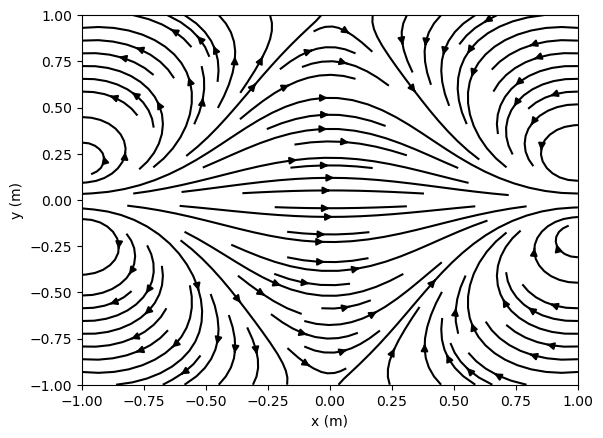

In [8]:
from bfield import mirror_B_field

x = np.linspace(-1.0, 1.0, 40)
y = np.linspace(-1.0, 1.0, 39)

X, Y = np.meshgrid(x, y)

B = np.vectorize(mirror_B_field)
Bx, By, Bz = B(X, Y, 0.0)
plt.streamplot(X, Y, Bx, By, color='k')
plt.xlabel('x (m)')
plt.ylabel('y (m)')

*Now try to place a 20 keV particle at different points in this field and watch what happens (try with different pitch angles)!*

In [9]:
# Your code here...